# Class evaluation

In this notebook we are trying to match all the keyword groups into documents to highlights specific patterns

## Load libraries

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [29]:
import pipeline.src.python.config as cfg
import pandas as pd
import numpy as np
pd.set_option('display.max_colwidth', None)
from bertopic import BERTopic
import polars as pl
import re

## Load data

In [45]:
cluster_df = pd.read_parquet('community_detection_results.parquet')

In [46]:
model_list = ['scopus','science_news','the_guardian']

In [47]:
class_eval_df = pd.DataFrame()

In [48]:
for model in model_list:
    
    cfg_dict = cfg.MAGAZINE_CONFIG[model]
    bertopic_model = BERTopic.load(cfg_dict['REFERENCE_MODEL'])

    model_data = np.load(cfg_dict['OUTPUT_PATH'],allow_pickle=True)

    dataset = pd.read_parquet(cfg_dict['DATASET_PATH'])
    
    tmp_df = bertopic_model.get_document_info(model_data['text'])['CustomName'].reset_index()
    tmp_df = tmp_df.drop(columns='index')

    tmp_df['id'] =  list(model_data['id'])
    tmp_df = tmp_df.rename(columns={'CustomName':'Topic Label'})
    
    tmp_df = tmp_df.merge(cluster_df,on='Topic Label')

    columns_to_mantain = ['id','text']
    columns_to_drop = [column for column in dataset.columns if column not in columns_to_mantain ]

    tmp_df = tmp_df.merge(dataset.drop(columns=columns_to_drop),on='id')

    class_eval_df = pd.concat([class_eval_df,tmp_df])


2026-02-19 17:50:44,750 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-02-19 17:50:54,589 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.
2026-02-19 17:50:56,130 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


In [55]:
class_eval_df_polars = pl.from_pandas(class_eval_df)

### Search keywords into datasets

In [51]:
from pipeline.src.python.data.interim.vocabulary.vocabulary import (
    BACTERIAL_PATHOGENS,
    SEQUENCING_METHODS,
    METHODS,
    EVOLUTION_MECHANISMS,
    EPIDEMIOLOGY_TRASMISSION,   
    SURVEILLANCE_AND_PUBLIC_HEALTH, 
    PLATFORM_AND_TECHNOLOGIES,  
    BIOINFORMATIC_TOOLS,    
    CONSORTIUM_AND_DATABASE,    
    VARIANT_AND_GENETIC_MARKER, 
    IMMUNOLOGY, 
    HAI,    
    AMR,    
    MOLECULAR_STRUCTURE,    
    VIRAL_PATHOGENS,    
    BACTERIAL_PATHOGENS,    
    OTHER_PATHOGENS,    
    WASTEWATER, 
    WARNING_SYSTEMS,    
    POLICY, 
    GENERIC_KEYWORDS,   
    COVID_SPECIFIC_KEYWORDS,    
    EPIDEMIC_MEASURES   
    )

In [52]:
words_dictionary = {
'BACTERIAL_PATHOGENS' : BACTERIAL_PATHOGENS,
'SEQUENCING_METHODS' : SEQUENCING_METHODS,
'METHODS' : METHODS,
'EVOLUTION_MECHANISMS' : EVOLUTION_MECHANISMS,
'EPIDEMIOLOGY_TRASMISSION' : EPIDEMIOLOGY_TRASMISSION,
'SURVEILLANCE_AND_PUBLIC_HEALTH': SURVEILLANCE_AND_PUBLIC_HEALTH,
'PLATFORM_AND_TECHNOLOGIES' : PLATFORM_AND_TECHNOLOGIES,
'BIOINFORMATIC_TOOLS' : BIOINFORMATIC_TOOLS,
'CONSORTIUM_AND_DATABASE' : CONSORTIUM_AND_DATABASE,
'VARIANT_AND_GENETIC_MARKER' : VARIANT_AND_GENETIC_MARKER,
'IMMUNOLOGY' : IMMUNOLOGY,
'HAI': HAI,
'AMR' : AMR,
'MOLECULAR_STRUCTURE' : MOLECULAR_STRUCTURE,
'VIRAL_PATHOGENS' : VIRAL_PATHOGENS,
'BACTERIAL_PATHOGENS' : BACTERIAL_PATHOGENS,
'OTHER_PATHOGENS' : OTHER_PATHOGENS,
'WASTEWATER' : WASTEWATER,
'WARNING_SYSTEMS' : WARNING_SYSTEMS,
'POLICY' : POLICY,
'GENERIC_KEYWORDS' : GENERIC_KEYWORDS,
'COVID_SPECIFIC_KEYWORDS' : COVID_SPECIFIC_KEYWORDS,
'EPIDEMIC_MEASURES' : EPIDEMIC_MEASURES
}

In [53]:
def search_keywords_by_category(df_polars: pl.DataFrame | pl.LazyFrame, words_dictionary : dict):

    new_columns = []

    for category, keywords in words_dictionary.items():

        pattern = '|'.join( [ re.escape(kw).replace(r'\-', r'[-\s]') for kw in keywords] )

        extracted = pl.col('text').str.replace('-',' ').str.extract_all(f'(?i)\\b({pattern})\\b')

        new_columns.extend([

        extracted.alias(f'{category}_matched'),

        ])

    return df_polars.with_columns(new_columns)

In [54]:
def count_list_elements(
    df: pl.DataFrame | pl.LazyFrame
) -> pl.DataFrame | pl.LazyFrame:

    count_expressions = []

    for col_name, dtype in df.collect_schema().items():

        if isinstance(dtype, pl.List) and dtype.inner == pl.Utf8:

            count_expr = (
                (pl.col(col_name).list.len() > 0)
                .cast(pl.Int8)
                .alias(f'n_{col_name}')
            )

            count_expressions.append(count_expr)

    if count_expressions:
        return df.with_columns(count_expressions)

    return df


In [56]:
polars_keywords_matched = search_keywords_by_category(class_eval_df_polars,words_dictionary=words_dictionary)

In [57]:
polars_keywords_matched = count_list_elements(polars_keywords_matched)

In [59]:
polars_keywords_matched = polars_keywords_matched.drop('text')

In [60]:
pandas_keywords_matched = polars_keywords_matched.to_pandas()

In [90]:
cluster_list = list(range(45))

In [91]:
class_eval_df_analysis = pandas_keywords_matched[ pandas_keywords_matched['Cluster'].isin(cluster_list) ]

In [92]:
if len(cluster_list) > 1:
    # Settare un identificativo per Cluster
    if 'Cluster Label' in class_eval_df_analysis.columns:
        class_eval_df_analysis['Graph_label'] = class_eval_df_analysis['Cluster Label']
    else:
        class_eval_df_analysis['Graph_label'] = class_eval_df_analysis['Cluster']
else:
    # Settare un identificativo per Topic Label
    class_eval_df_analysis['Graph_label'] = class_eval_df_analysis['Topic Label']

In [93]:
result = (
    class_eval_df_analysis
        .groupby('Graph_label')
        .agg(
            **{col: (col, 'mean') for col in class_eval_df_analysis.columns if col.startswith('n_')},
            n_rows=('Graph_label', 'size')
        )
)

In [94]:
result

,n_BACTERIAL_PATHOGENS_matched,n_SEQUENCING_METHODS_matched,n_METHODS_matched,n_EVOLUTION_MECHANISMS_matched,n_EPIDEMIOLOGY_TRASMISSION_matched,n_SURVEILLANCE_AND_PUBLIC_HEALTH_matched,n_PLATFORM_AND_TECHNOLOGIES_matched,n_BIOINFORMATIC_TOOLS_matched,n_CONSORTIUM_AND_DATABASE_matched,n_VARIANT_AND_GENETIC_MARKER_matched,...,n_MOLECULAR_STRUCTURE_matched,n_VIRAL_PATHOGENS_matched,n_OTHER_PATHOGENS_matched,n_WASTEWATER_matched,n_WARNING_SYSTEMS_matched,n_POLICY_matched,n_GENERIC_KEYWORDS_matched,n_COVID_SPECIFIC_KEYWORDS_matched,n_EPIDEMIC_MEASURES_matched,n_rows
Graph_label,,,,,,,,,,,,,,,,,,,,,
AntimicrobialResistance Challenges,0.429148,0.052278,0.103379,0.025887,0.097495,0.152631,0.018827,0.000504,0.000336,0.098000,...,0.000000,0.019499,0.009581,0.006220,0.002858,0.034964,0.857287,0.000840,0.011262,5949
Antiviral Treatments and Therapies,0.014972,0.007092,0.014184,0.003940,0.049645,0.016548,0.002364,0.004728,0.003940,0.314421,...,0.138692,0.700552,0.009456,0.000000,0.000000,0.011032,0.980299,0.111899,0.113475,1269
Bacterial Communication and Infection,0.843750,0.003125,0.015625,0.031250,0.453125,0.006250,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.006250,0.003125,0.003125,0.000000,0.006250,0.909375,0.000000,0.021875,320
Biological Research Innovations,0.166667,0.000000,0.211111,0.022222,0.022222,0.011111,0.000000,0.000000,0.011111,0.011111,...,0.000000,0.544444,0.111111,0.000000,0.000000,0.022222,0.922222,0.011111,0.122222,90
Blood Safety and Infections,0.034653,0.004950,0.049505,0.000000,0.014851,0.039604,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.900990,0.034653,0.000000,0.000000,0.009901,0.851485,0.000000,0.019802,202
Bovine TB and Badgers,0.915579,0.046815,0.116654,0.001535,0.382962,0.106677,0.009210,0.000000,0.000000,0.001535,...,0.000000,0.018419,0.001535,0.000000,0.000000,0.002302,0.871067,0.000000,0.126631,1303
Contact Tracing and Surveillance,0.005474,0.000000,0.023723,0.001825,0.034672,0.129562,0.000000,0.000000,0.000000,0.003650,...,0.000000,0.173358,0.001825,0.000000,0.010949,0.007299,0.981752,0.036496,0.293796,548
Coronavirus Research and Response,0.005671,0.065215,0.092667,0.021008,0.105039,0.115221,0.023586,0.028612,0.044851,0.182498,...,0.082743,0.582936,0.002964,0.000000,0.005026,0.041887,0.994071,0.242170,0.356360,7759
Covid-19 Testing Challenges,0.000000,0.021505,0.037634,0.000000,0.053763,0.043011,0.016129,0.000000,0.000000,0.215054,...,0.005376,0.645161,0.000000,0.000000,0.000000,0.016129,1.000000,0.247312,0.155914,186


In [95]:
import plotly.express as px

# rimuovo la colonna di conteggio
heatmap_df = result.drop(columns=['n_rows'])


In [96]:
heatmap_df = heatmap_df.rename(
    columns=lambda c: (
        c.replace('n_', '')
         .replace('_matched', '')
         .replace('_', ' ')
         .title()
    )
)


In [97]:
import plotly.graph_objects as go
import numpy as np

# Ordina colonne per media decrescente e righe per somma decrescente
ordered_cols = heatmap_df.mean().sort_values(ascending=False).index
ordered_rows = heatmap_df.sum(axis=1).sort_values(ascending=False).index
df_sorted = heatmap_df.loc[ordered_rows, ordered_cols]

# Normalizza i valori per le annotazioni (opzionale)
z = df_sorted.values
z_text = np.round(z, 2).astype(str)

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=list(df_sorted.columns),
    y=list(df_sorted.index),
    text=z_text,
    texttemplate="%{text}",
    textfont={"size": 9},
    colorscale="RdYlGn",           # Scala più intuitiva: rosso → giallo → verde
    colorbar=dict(
        title=dict(text="Valore", side="right"),
        thickness=15,
        len=0.8,
        tickfont=dict(size=11),
    ),
    hoverongaps=False,
    hovertemplate=(
        "<b>Riga:</b> %{y}<br>"
        "<b>Colonna:</b> %{x}<br>"
        "<b>Valore:</b> %{z:.3f}<extra></extra>"
    ),
))

fig.update_layout(
    title=dict(
        text="Heatmap — Distribuzione dei valori",
        font=dict(size=18, color="#2c3e50"),
        x=0.5,
        xanchor="center"
    ),
    height=max(500, 30 * len(df_sorted)),  # Altezza dinamica in base alle righe
    margin=dict(l=120, r=80, t=80, b=140),
    font=dict(family="Arial, sans-serif", size=11, color="#2c3e50"),
    paper_bgcolor="#f8f9fa",
    plot_bgcolor="#ffffff",
    xaxis=dict(
        tickangle=-40,
        tickfont=dict(size=10),
        side="bottom",
        title="",
    ),
    yaxis=dict(
        tickfont=dict(size=10),
        autorange="reversed",   # Mantiene l'ordine top→bottom
        title="",
    ),
)

# Linee di separazione tra celle (griglia visiva)
fig.update_traces(
    xgap=1,
    ygap=1,
)

fig.show()

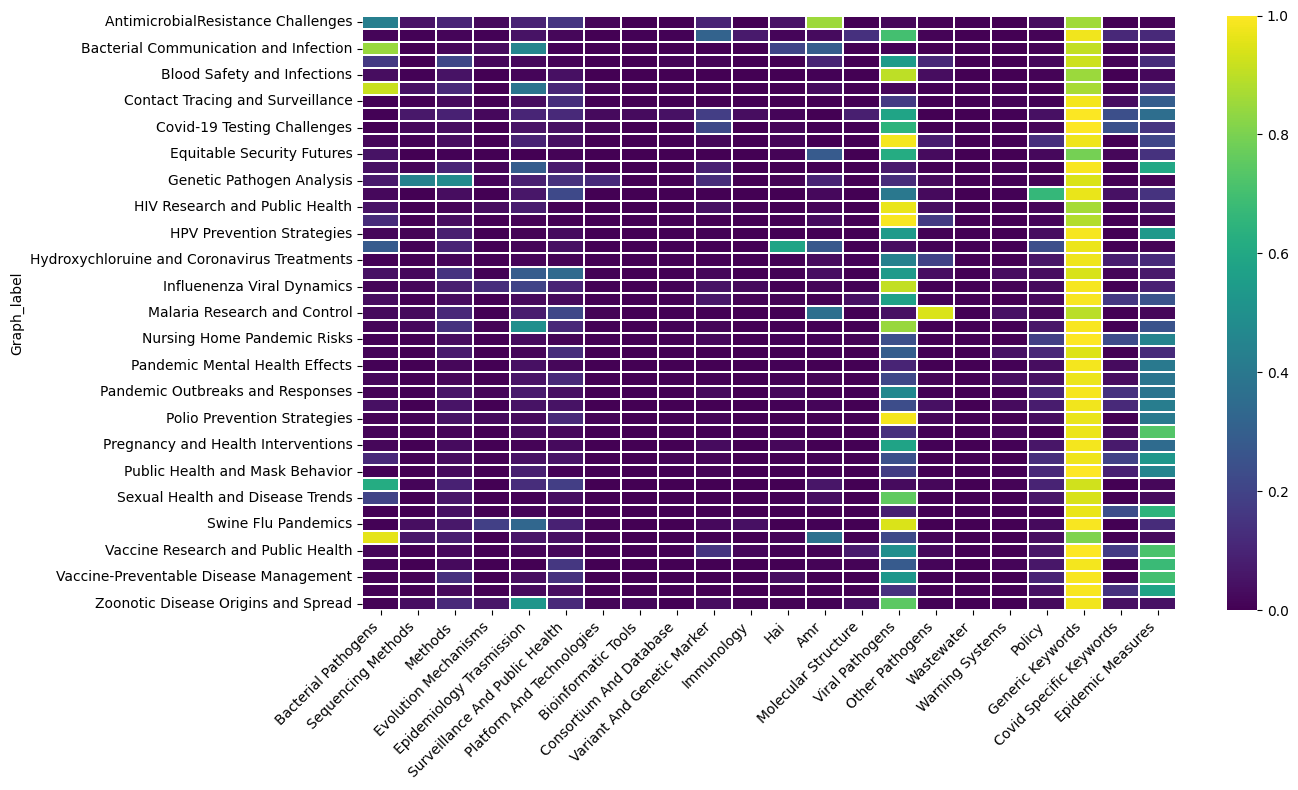

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_df,
    cmap='viridis',
    linewidths=0.2
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
